# Klasifikace LEGO minifigurek pomocí CNN

**Dataset:** LEGO Minifigures Classification — [Kaggle (ihelon)](https://www.kaggle.com/datasets/ihelon/lego-minifigures-classification)  
**Cíl:** Rozpoznání 38 různých postav LEGO ze čtyř sérií (Marvel, Star Wars, Harry Potter, Jurassic World)  
**Přístupy:** Vlastní CNN od nuly · Transfer Learning (MobileNetV2)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

# GPU konfigurace
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU nalezeno: {gpus[0].name}")
else:
    print("GPU nenalezeno – trening bezi na CPU.")

DATA_DIR    = "data"
IMG_SIZE    = 96
BATCH_SIZE  = 16   # mene samplu/batch → vice aktualizaci vah za epochu
NUM_CLASSES = 38
EPOCHS      = 100

print(f"\nTensorFlow {tf.__version__}")

GPU nalezeno: /physical_device:GPU:0

TensorFlow 2.21.0


## 1. Dokumentace datasetu

In [58]:
df      = pd.read_csv(f"{DATA_DIR}/index.csv")
meta    = pd.read_csv(f"{DATA_DIR}/metadata.csv", encoding='cp1252')
df_test = pd.read_csv(f"{DATA_DIR}/test.csv")

df = df.merge(meta[['class_id', 'minifigure_name']], on='class_id')
df['series']    = df['path'].str.split('/').str[0]
df['full_path'] = DATA_DIR + '/' + df['path']
df_test['full_path'] = DATA_DIR + '/' + df_test['path']

class_counts = df.groupby('minifigure_name').size()

print(f"{'Trénovacích obrázků:':<32} {len(df)}")
print(f"{'Testovacích obrázků:':<32} {len(df_test)}")
print(f"{'Počet tříd:':<32} {df['class_id'].nunique()}")
print(f"{'Min / max / průměr / třída:':<32} {class_counts.min()} / {class_counts.max()} / {class_counts.mean():.1f}")
print()
print(df.groupby('series')['class_id'].nunique().rename('# tříd').to_string())

Trénovacích obrázků:             371
Testovacích obrázků:             79
Počet tříd:                      38
Min / max / průměr / třída:      7 / 18 / 10.0

series
harry-potter       2
jurassic-world     2
marvel            17
star-wars         17


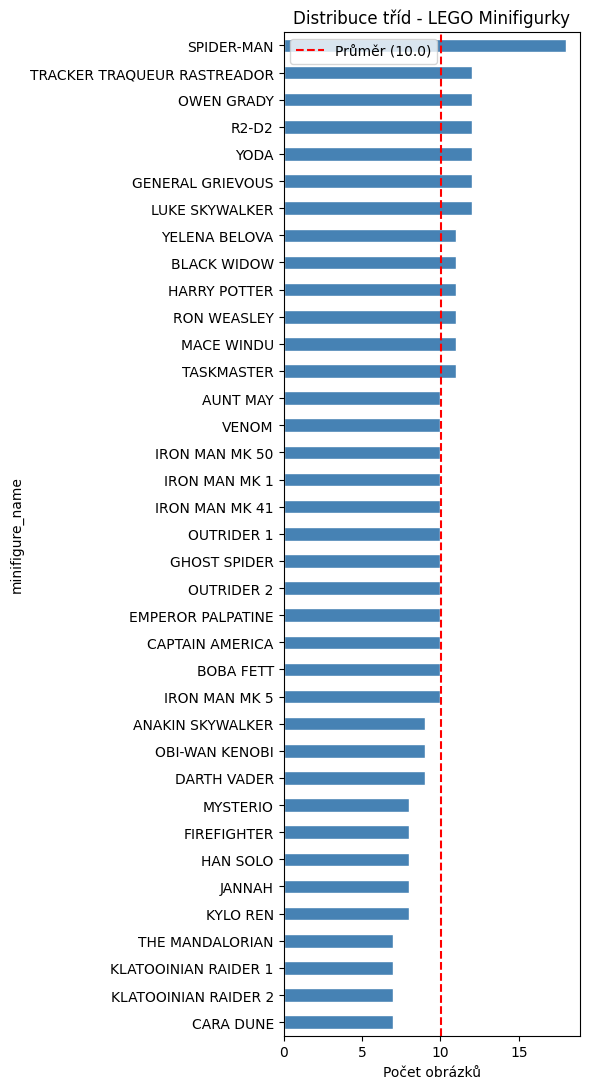

In [59]:
fig, ax = plt.subplots(figsize=(6, 11))
class_counts.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.axvline(class_counts.mean(), color='red', ls='--', lw=1.5,
           label=f'Průměr ({class_counts.mean():.1f})')
ax.set_xlabel('Počet obrázků')
ax.set_title('Distribuce tříd - LEGO Minifigurky')
ax.legend()
plt.tight_layout()
plt.show()

Dataset je velmi dobre vyvazeny (rozsah 7-18 obrazku na tridu).

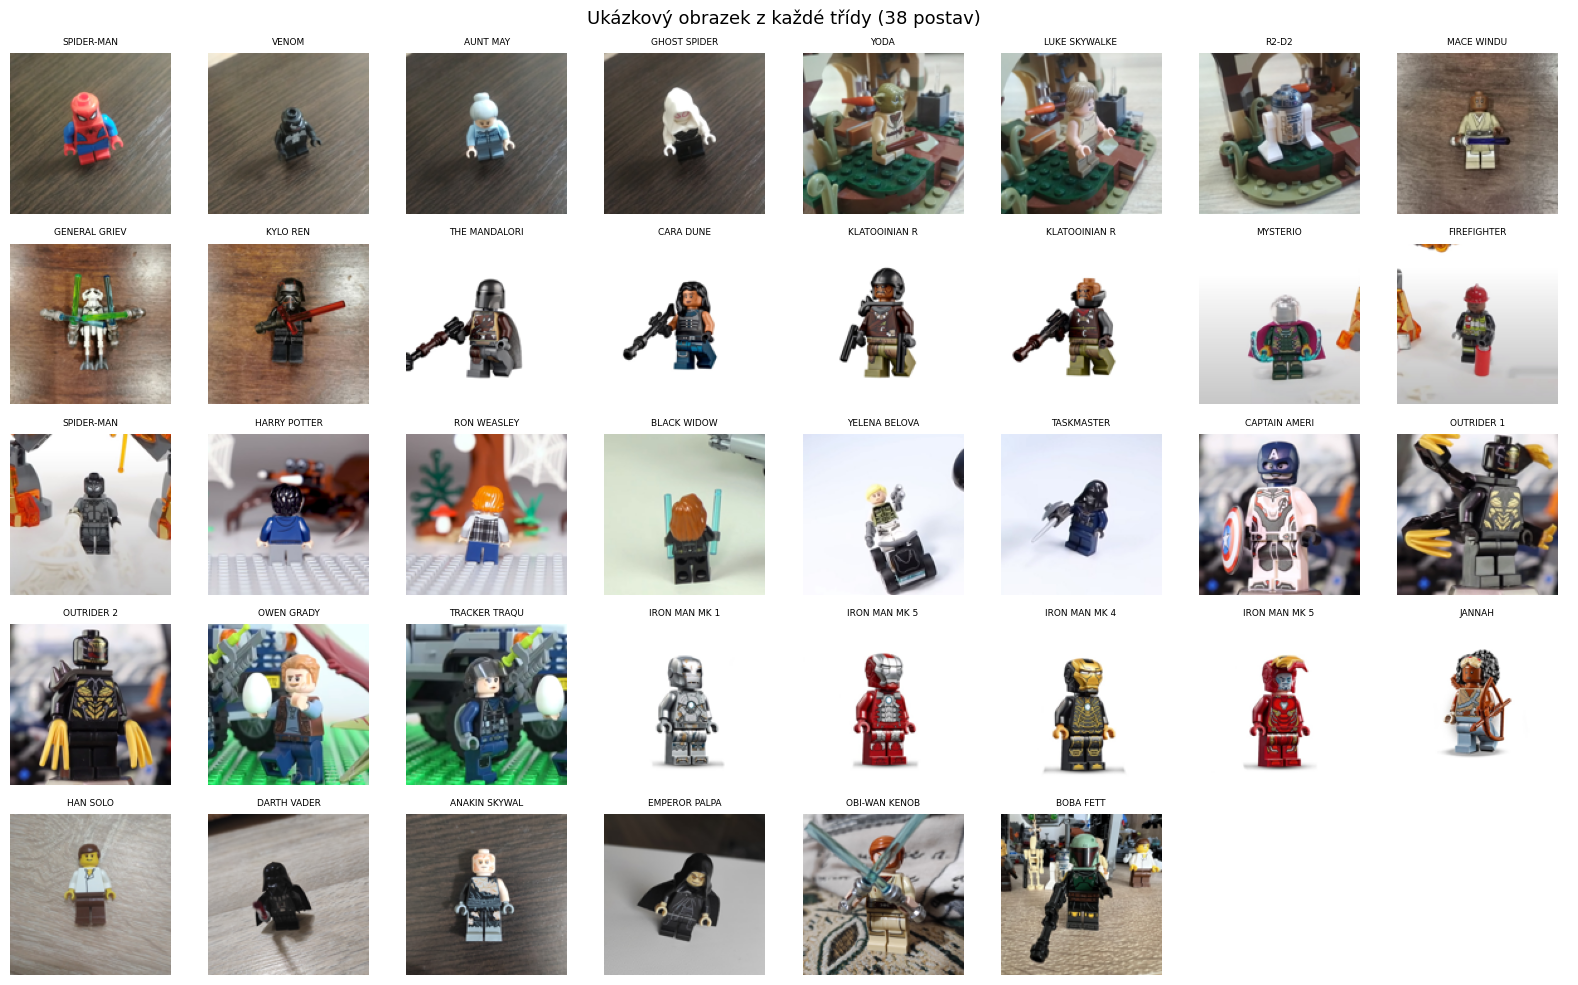

In [60]:
sample = df.groupby('class_id').first().reset_index()
fig, axes = plt.subplots(5, 8, figsize=(16, 10))
axes = axes.flatten()
for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row['full_path']).resize((128, 128))
    axes[i].imshow(img)
    axes[i].set_title(row['minifigure_name'][:13], fontsize=6.5)
    axes[i].axis('off')
for j in range(len(sample), len(axes)):
    axes[j].axis('off')
plt.suptitle('Ukázkový obrazek z každé třídy (38 postav)', fontsize=13)
plt.tight_layout()
plt.show()

**Pozorování:**
- Obrázky jsou 512×512 px, fotografie na bílém/neutrálním pozadí.
- Figurky mají stejné tělesné proporce — model musí rozlišit jemné detaily (barva, přílba, vzory na torzu).
- Extrémně malý dataset (~10 vzorků/třída) → nutná agresivní augmentace a transfer learning.

## 2. Příprava dat

In [61]:
def load_images(dataframe, img_size=IMG_SIZE):
    """Načte obrázky do numpy pole, normalizuje do [0, 1]."""
    X, y = [], []
    for _, row in dataframe.iterrows():
        img = Image.open(row['full_path']).convert('RGB').resize((img_size, img_size))
        X.append(np.array(img, dtype=np.float32) / 255.0)
        y.append(int(row['class_id']) - 1)  # 0-indexovane
    return np.array(X), np.array(y)

# Stratifikovany split 80 / 20
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['class_id']
)
print(f"Trénink: {len(train_df)} | Validace: {len(val_df)} | Test: {len(df_test)}")

print("Načítám obrázky...")
X_train, y_train = load_images(train_df)
X_val,   y_val   = load_images(val_df)
X_test,  y_test  = load_images(df_test)
print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")

Trénink: 296 | Validace: 75 | Test: 79
Načítám obrázky...
X_train: (296, 96, 96, 3)  X_val: (75, 96, 96, 3)  X_test: (79, 96, 96, 3)


## 3. Výběr hodnotících metrik

| Metrika | Popis |
|---|---|
| **Accuracy** | Celkový podíl správných predikcí |
| **F1-score (macro)** | Průměr F1 přes všechny třídy bez vážení — **hlavní metrika** |
| **Confusion matrix** | Vizualizace záměn mezi třídami |

**Hlavní metrika: F1-macro.**  
Přestože jsou třídy vyvážené, každá má jen 7–12 vzorků — F1-macro penalizuje špatnou klasifikaci
libovolné třídy stejnou měrou a lépe odhalí problémy s konkrétními podobnými postavami.
Accuracy je sekundární metrika pro snadnou interpretaci.

**Poznámka k EarlyStopping:** Monitorujeme `val_accuracy` místo `val_loss`.
Na validační sadě s pouhými 75 vzorky může `val_loss` klesat, zatímco `val_accuracy` stagnuje — nebo naopak: epocha s nejnižším `val_loss` nemusí odpovídat nejlepší přesnosti. `ReduceLROnPlateau` nadále sleduje `val_loss`, protože ten poskytuje hladší signál pro snížení LR.

In [62]:
def evaluate_model(model, X, y_true, label="Model"):
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"{label:<45}  Accuracy={acc:.4f}  F1-macro={f1:.4f}")
    return acc, f1, y_pred

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'],     label='trenink')
    ax1.plot(history.history['val_accuracy'], label='validace')
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epocha')
    ax1.legend()
    ax2.plot(history.history['loss'],     label='trenink')
    ax2.plot(history.history['val_loss'], label='validace')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epocha')
    ax2.legend()
    plt.tight_layout()
    plt.show()

base_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=20, mode='max',  # val_loss != proxy pro acc na malém datasetu
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8, verbose=0
    ),
]

## 4. Model 1 – Vlastní CNN

**Architektura (VGG-style):** 3 bloky, každý s dvojicí konvolucí a následným MaxPoolingem.  
Prostorové rozlišení: 96→48→24→12 px; GlobalAveragePooling místo Flatten.  
Inicializace `he_normal` je vhodná pro aktivaci ReLU (udržuje rozptyl gradientů napříč vrstvami).

**Augmentace** (pouze při tréninku): horizontální zrcadlení, rotace ±10°, zoom ±10 %.

| Varianta | Změna |
|---|---|
| **CNN + BN + Adam** | hlavní model |
| **CNN bez BN** | zjistit vliv BatchNorm na konvergenci |
| **CNN + BN + SGD** | porovnání optimalizátorů |

In [63]:
def build_cnn(use_bn=True, optimizer='adam', name="CNN"):
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Pouze prostorová augmentace (flip + rotace + zoom)
    x = layers.RandomFlip("horizontal")(inp)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)

    # Blok 1 – 32 filtru
    x = layers.Conv2D(32, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal')(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal')(x)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)       # 96 → 48
    x = layers.Dropout(0.2)(x)

    # Blok 2 – 64 filtru
    x = layers.Conv2D(64, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal')(x)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)       # 48 → 24
    x = layers.Dropout(0.2)(x)

    # Blok 3 – 128 filtru
    x = layers.Conv2D(128, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal')(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal')(x)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)       # 24 → 12

    # Klasifikacni hlava
    x = layers.GlobalAveragePooling2D()(x)   # → [batch, 128]
    x = layers.Dense(256, activation='relu',
                     kernel_initializer='he_normal')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    opt = keras.optimizers.Adam(1e-3) if optimizer == 'adam' else optimizer
    model = models.Model(inp, out, name=name)
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_main = build_cnn(use_bn=True, optimizer='adam', name="CNN_BN_Adam")
cnn_main.summary()

Model: "CNN_BN_Adam"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_12 (RandomFlip)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_12              │ (None, 96, 96, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_12 (RandomZoom)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_12     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 330,694 (1.26 MB)

 Trainable params: 330,246 (1.26 MB)

 Non-trainable params: 448 (1.75 KB)

In [64]:
history_cnn = cnn_main.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=base_callbacks,
    verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.0405 - loss: 3.9966 - val_accuracy: 0.0133 - val_loss: 3.6787 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.0777 - loss: 3.4750 - val_accuracy: 0.0133 - val_loss: 4.0073 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.0946 - loss: 3.2927 - val_accuracy: 0.0533 - val_loss: 3.8524 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.1318 - loss: 3.0099 - val_accuracy: 0.0533 - val_loss: 4.1456 - learning_rate: 0.0010
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1622 - loss: 2.9935 - val_accuracy: 0.0267 - val_loss: 4.3680 - learning_rate: 0.0010
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.1655 - loss: 2.9055 - val_accuracy: 0.0667 - val_loss: 4.0738 - learning_rate: 0.0010
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.2230 - loss: 2.6855 - 

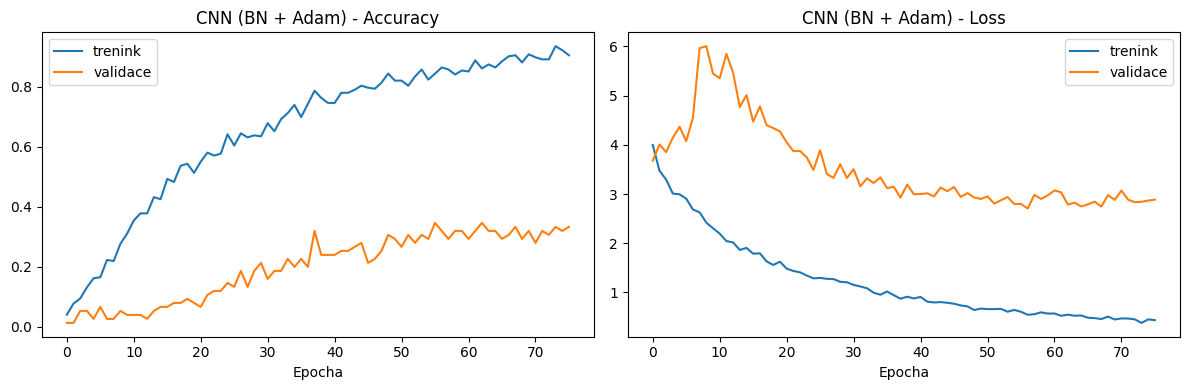

CNN (BN+Adam) - validace                       Accuracy=0.3467  F1-macro=0.3378
CNN (BN+Adam) - test                           Accuracy=0.1519  F1-macro=0.1229


In [65]:
plot_history(history_cnn, "CNN (BN + Adam)")
acc_cnn,   f1_cnn,   pred_cnn_val = evaluate_model(cnn_main, X_val,  y_val,  "CNN (BN+Adam) - validace")
acc_cnn_t, f1_cnn_t, pred_cnn_t   = evaluate_model(cnn_main, X_test, y_test, "CNN (BN+Adam) - test")

### Experimenty – vliv BatchNormalization a optimalizátoru

Trénujeme tři varianty se shodnou architekturou, měníme vždy jen jeden parametr.

Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 1.
CNN (bez BN) - validace                        Accuracy=0.0267  F1-macro=0.0014


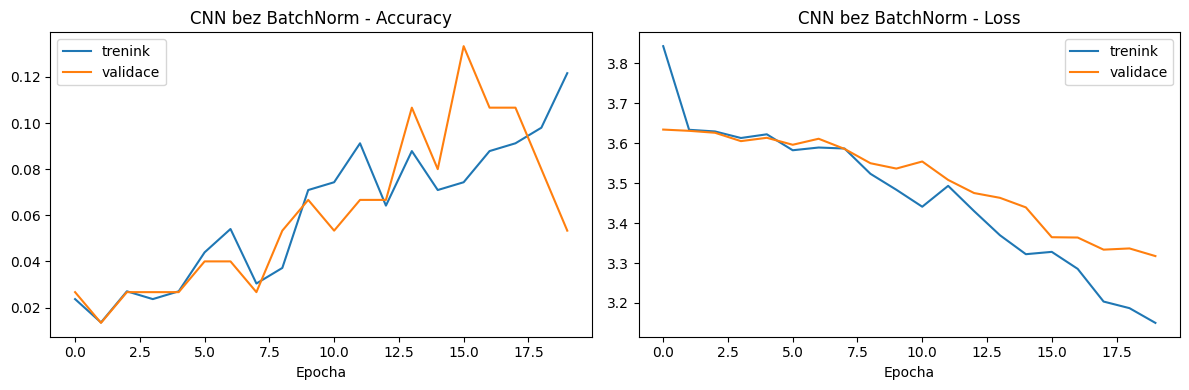

In [66]:
# Experiment 1: bez BatchNormalization
tf.random.set_seed(42)
np.random.seed(42)
cnn_nobn = build_cnn(use_bn=False, optimizer='adam', name="CNN_noBN")
history_nobn = cnn_nobn.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=base_callbacks, verbose=0
)
acc_nobn, f1_nobn, _ = evaluate_model(cnn_nobn, X_val, y_val, "CNN (bez BN) - validace")
plot_history(history_nobn, "CNN bez BatchNorm")

Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 1.
CNN (BN + SGD) - validace                      Accuracy=0.0400  F1-macro=0.0020


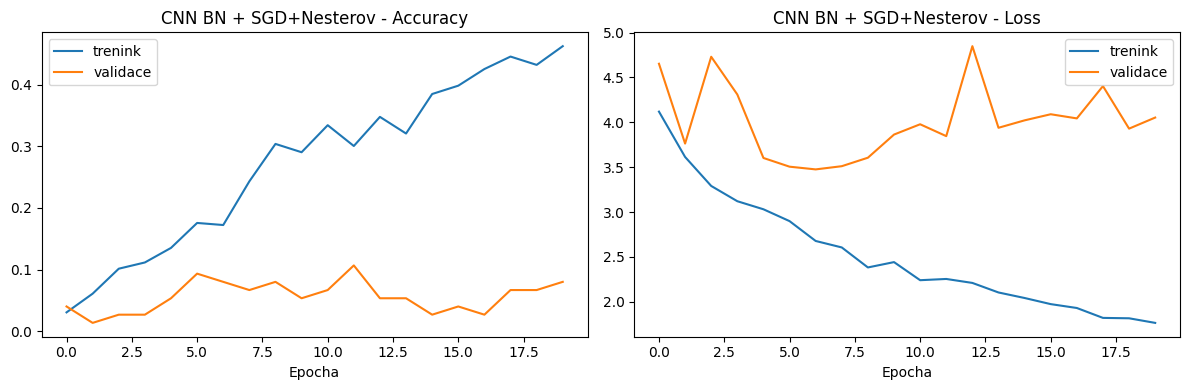

In [67]:
# Experiment 2: SGD + Nesterov momentum misto Adam
tf.random.set_seed(42)
np.random.seed(42)
sgd = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
cnn_sgd = build_cnn(use_bn=True, optimizer=sgd, name="CNN_BN_SGD")
history_sgd = cnn_sgd.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=base_callbacks, verbose=0
)
acc_sgd, f1_sgd, _ = evaluate_model(cnn_sgd, X_val, y_val, "CNN (BN + SGD) - validace")
plot_history(history_sgd, "CNN BN + SGD+Nesterov")

In [68]:
exp_df = pd.DataFrame({
    'Varianta':     ['CNN + BN + Adam', 'CNN bez BN + Adam', 'CNN + BN + SGD+Nesterov'],
    'Val Accuracy': [f"{acc_cnn:.4f}",  f"{acc_nobn:.4f}",  f"{acc_sgd:.4f}"],
    'Val F1-macro': [f"{f1_cnn:.4f}",   f"{f1_nobn:.4f}",   f"{f1_sgd:.4f}"],
    'Epochy':       [
        len(history_cnn.history['loss']),
        len(history_nobn.history['loss']),
        len(history_sgd.history['loss'])
    ],
})
exp_df

,Varianta,Val Accuracy,Val F1-macro,Epochy
0,CNN + BN + Adam,0.3467,0.3378,76
1,CNN bez BN + Adam,0.0267,0.0014,20
2,CNN + BN + SGD+Nesterov,0.0400,0.0020,20


**Pozorování:**
- **BatchNorm je klíčový** — bez BN model vůbec nekonverguje (val 2.67 % — shodné s náhodným baseline 2.63 %). VGG-style síť se 6 vrstvami bez normalizace trpí nestabilními gradienty.
- **Adam vs SGD:** Adam (adaptive LR) jasně překonal SGD (lr=0.01) — SGD vyžaduje přesné ladění LR a na malém datasetu nenajde optimum; Adam se adaptuje automaticky.

## 5. Model 2 – Transfer Learning (MobileNetV2)

MobileNetV2 předtrénovaný na ImageNet (1,4 M obrázků, 1000 tříd) — váhy zachycují
obecné vizuální příznaky (hrany, textury, tvary), které jsou přenositelné na LEGO figurky.

**Fáze 1 – Feature extraction:** Báze zmrazena, trénujeme pouze klasifikační hlavu.  
**Fáze 2 – Fine-tuning:** Odmrazíme posledních 15 vrstev, doladíme s velmi nízkým LR (5e-6).

**Poznámka k training argumentu:** `base_model` voláme bez `training` argumentu — Keras automaticky použije inference mód (BN používá running statistics), protože `base_model.trainable = False`. Ve Fázi 2 po nastavení `base_model.trainable = True` Keras přepne na training mód automaticky.

In [69]:
base_model = MobileNetV2(
    weights='imagenet', include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False
print(f"MobileNetV2: {len(base_model.layers)} vrstev, {base_model.count_params():,} parametru")

inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = layers.RandomFlip("horizontal")(inp)
x = layers.RandomRotation(0.15)(x)
x = layers.RandomZoom(0.15)(x)
# MobileNetV2 ocekava vstup v [-1, 1]; prevedeme z [0, 1]
x = layers.Rescaling(2.0, offset=-1.0)(x)
x = base_model(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
tl_model = models.Model(inp, out, name="TL_MobileNetV2")

tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tl_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8, verbose=0
    ),
]

print("Faze 1 - trenink klasifikacni hlavy (baze zmrazena)")
history_tl1 = tl_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=100, batch_size=BATCH_SIZE,
    callbacks=tl_callbacks, verbose=1
)


MobileNetV2: 154 vrstev, 2,257,984 parametru
Faze 1 - trenink klasifikacni hlavy (baze zmrazena)
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.0405 - loss: 4.1533 - val_accuracy: 0.0933 - val_loss: 3.4301 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1182 - loss: 3.2171 - val_accuracy: 0.1733 - val_loss: 3.1380 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3378 - loss: 2.6706 - val_accuracy: 0.3467 - val_loss: 2.7154 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3818 - loss: 2.2011 - val_accuracy: 0.4267 - val_loss: 2.3215 - learning_rate: 0.0010
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4797 - loss: 1.8322 - val_accuracy: 0.5067 - val_loss: 2.0053 - learning_rate: 0.0010
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5743 - loss: 1.4945 - val_accuracy: 0.4667 - val_loss: 1.8339 - learning_rate

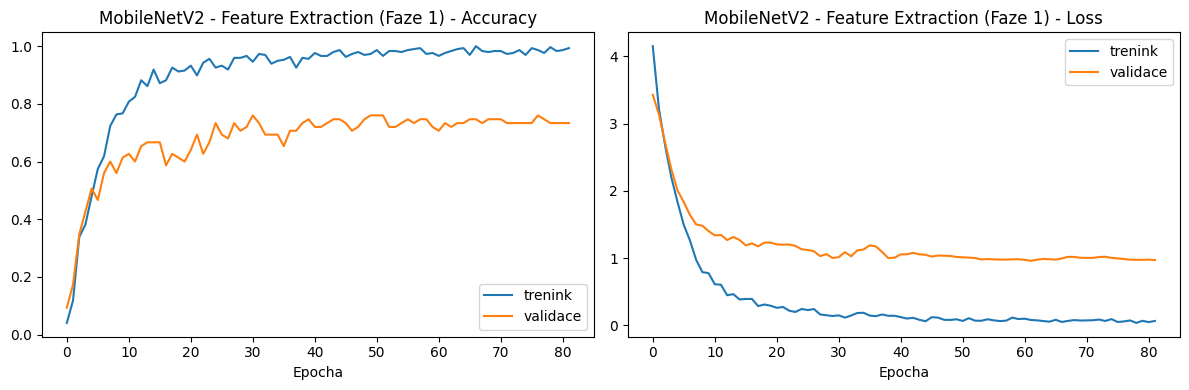

MobileNetV2 Faze 1 (frozen) - validace         Accuracy=0.7333  F1-macro=0.6965


(0.7333333333333333,
 0.6964912280701755,
 array([10, 25,  3,  5, 17, 27, 29, 24,  2, 30, 28, 32, 26,  1, 16, 14, 30,
        12, 25, 31, 14,  4,  5, 21,  8, 28, 32, 28, 15,  9, 22, 32, 37,  6,
         6,  4, 32, 35, 36, 18, 19,  7, 23,  7,  9, 20, 15, 34, 22,  2, 19,
        17, 12, 26, 31, 26, 34,  0, 34, 21, 36,  3, 14,  8, 29,  5, 29, 33,
        35, 37, 20, 26, 30,  8, 16]))

In [70]:
plot_history(history_tl1, "MobileNetV2 - Feature Extraction (Faze 1)")
evaluate_model(tl_model, X_val, y_val, "MobileNetV2 Faze 1 (frozen) - validace")

In [71]:
base_model.trainable = True
for layer in base_model.layers[:-15]:
    layer.trainable = False
print(f"Trénovaných vrstev v bázi: {sum(l.trainable for l in base_model.layers)}/{len(base_model.layers)}")

tl_model.compile(
    optimizer=keras.optimizers.Adam(5e-6),  # Konzervativni LR pro fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# DULEZITE: nove instance callbacku – Phase 1 callback ma ulozeny stav (best val_loss)
# a Phase 2 by ho nikdy neprekonal → trening by okamzite skoncil
tl_callbacks_p2 = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=6, verbose=0
    ),
]

history_tl2 = tl_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=50, batch_size=BATCH_SIZE,
    callbacks=tl_callbacks_p2, verbose=1
)

Trénovaných vrstev v bázi: 15/154
Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.7534 - loss: 0.8602 - val_accuracy: 0.7333 - val_loss: 0.9596 - learning_rate: 5.0000e-06
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7804 - loss: 0.7620 - val_accuracy: 0.7467 - val_loss: 0.9582 - learning_rate: 5.0000e-06
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7466 - loss: 0.8221 - val_accuracy: 0.7333 - val_loss: 0.9587 - learning_rate: 5.0000e-06
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7838 - loss: 0.6861 - val_accuracy: 0.7467 - val_loss: 0.9593 - learning_rate: 5.0000e-06
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7770 - loss: 0.6923 - val_accuracy: 0.7333 - val_loss: 0.9555 - learning_rate: 5.0000e-06
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7736 - loss: 0.7223 - val_accuracy: 0.7333 - val_loss: 0.9520 - learning_rate: 5.0000e-06
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━

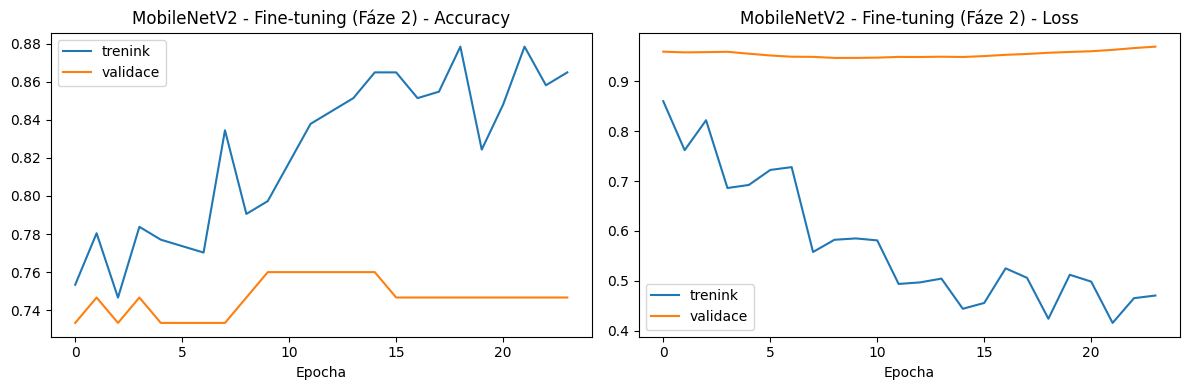

MobileNetV2 (fine-tuned) - validace            Accuracy=0.7467  F1-macro=0.7035
MobileNetV2 (fine-tuned) - test                Accuracy=0.6329  F1-macro=0.5615


In [72]:
plot_history(history_tl2, "MobileNetV2 - Fine-tuning (Fáze 2)")
acc_tl,   f1_tl,   pred_tl_val = evaluate_model(tl_model, X_val,  y_val,  "MobileNetV2 (fine-tuned) - validace")
acc_tl_t, f1_tl_t, pred_tl_t   = evaluate_model(tl_model, X_test, y_test, "MobileNetV2 (fine-tuned) - test")

**Pozorování k Fine-tuningu:**
- Fáze 1 → Fáze 2: val accuracy se mírně zlepšila (73.33 % → 74.67 %) — fine-tuning mírně pomohl.
- Model dosáhl nejlepší val_accuracy v epoše 10 Fáze 2; EarlyStopping (val_loss) obnovil váhy z epochy 9.
- **Val vs Test gap (~10 %):** validační sada má pouze 75 vzorků (~2 na třídu), odhad accuracy je hlučný.

## 6. Porovnání modelů

In [73]:
comparison = pd.DataFrame({
    'Model':         ['Vlastni CNN', 'MobileNetV2 (Transfer Learning)'],
    'Val Accuracy':  [f"{acc_cnn:.4f}",   f"{acc_tl:.4f}"],
    'Val F1-macro':  [f"{f1_cnn:.4f}",    f"{f1_tl:.4f}"],
    'Test Accuracy': [f"{acc_cnn_t:.4f}", f"{acc_tl_t:.4f}"],
    'Test F1-macro': [f"{f1_cnn_t:.4f}",  f"{f1_tl_t:.4f}"],
    'Parametrů':     [f"{cnn_main.count_params():,}", f"{tl_model.count_params():,}"],
})
print(comparison.to_string(index=False))

                          Model Val Accuracy Val F1-macro Test Accuracy Test F1-macro Parametrů
                    Vlastni CNN       0.3467       0.3378        0.1519        0.1229   330,694
MobileNetV2 (Transfer Learning)       0.7467       0.7035        0.6329        0.5615 2,426,854


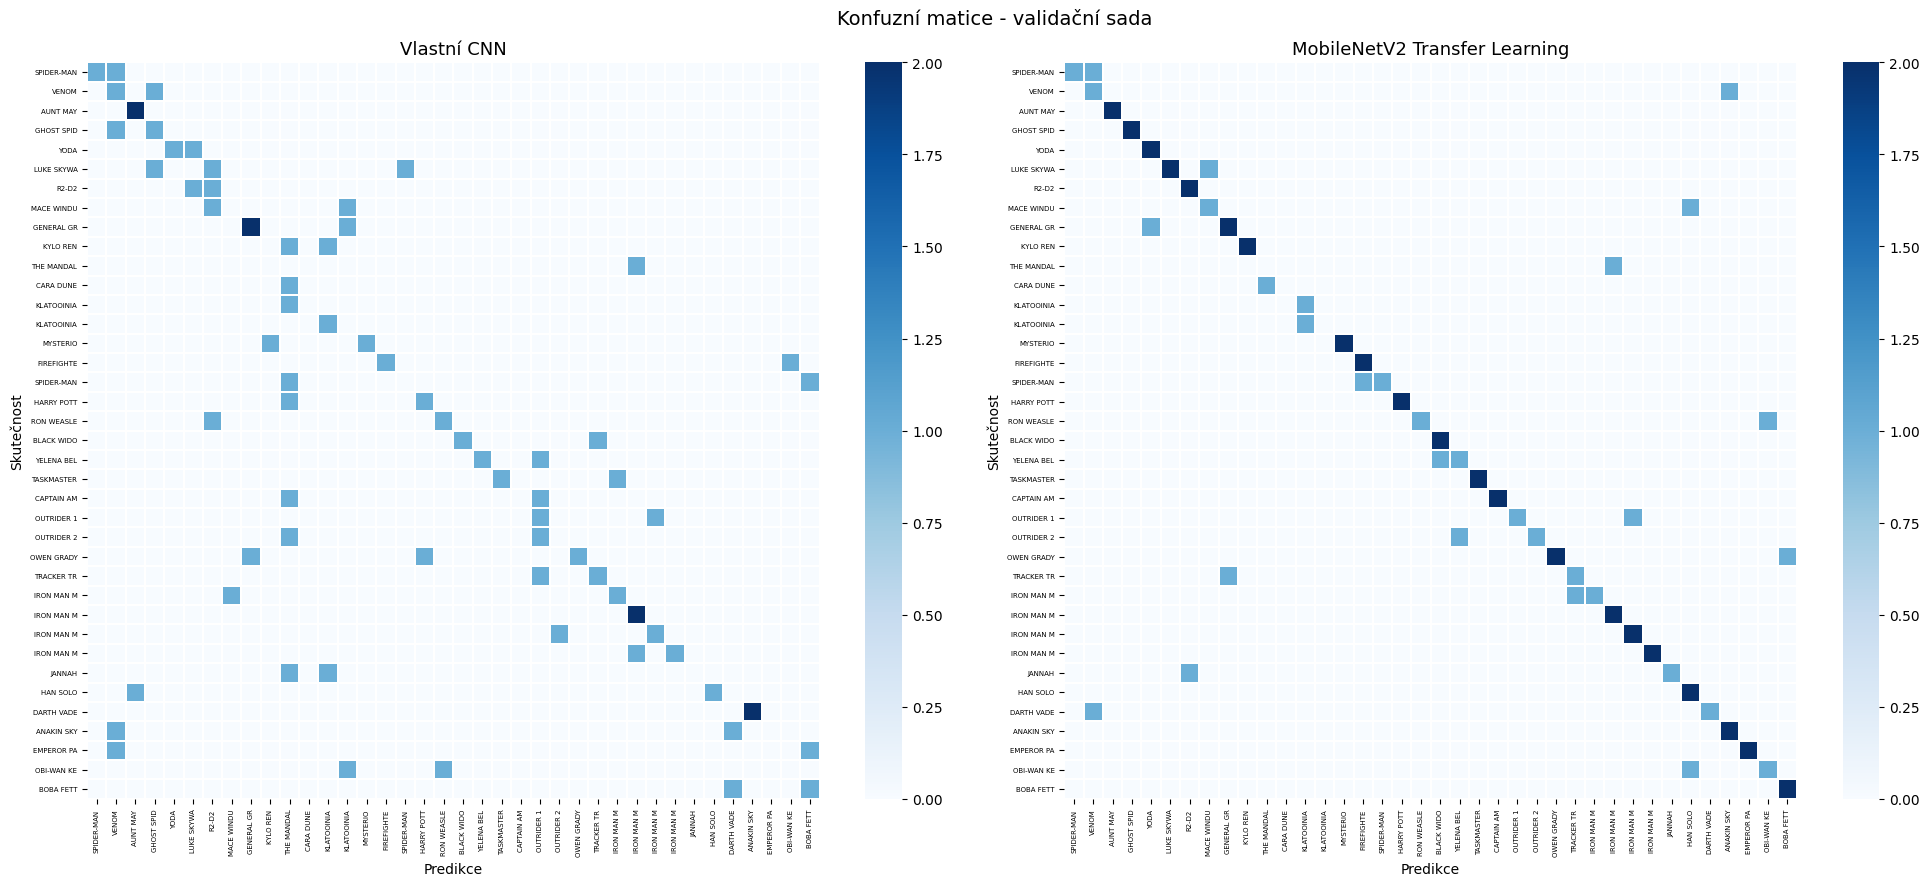

In [74]:
class_names = (
    meta.sort_values('class_id')['minifigure_name']
    .str[:10]
    .tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
for ax, (y_pred, title) in zip(axes, [
    (pred_cnn_val, 'Vlastní CNN'),
    (pred_tl_val,  'MobileNetV2 Transfer Learning')
]):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(
        cm, ax=ax, cmap='Blues', linewidths=0.3,
        xticklabels=class_names, yticklabels=class_names
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Predikce')
    ax.set_ylabel('Skutečnost')
    ax.tick_params(labelsize=5)
plt.suptitle('Konfuzní matice - validační sada', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Závěr – klíčové poznatky

### Dataset
- **371 trénovaných** + **79 testovacích** obrázků, **38 tříd** ze 4 sérií LEGO (Marvel, Star Wars, Harry Potter, Jurassic World).
- Třídy jsou výborně vyváženy (7–18 obrázků/třída), ale objem dat je extrémně malý (~8 vzorků/třída).
- Vizuálně velmi podobné figurky (stejné proporce) — nutné rozlišit jemné detaily.

### Vlastní CNN
- **Klíčový poznatek – BatchNorm:** VGG-style architektura bez BN vůbec nekonverguje (val 2.67 %). S BN dosáhla val 34.67 % — normalizace je pro hlubší sítě na malém datasetu nezbytná.
- **Adam vs SGD:** Adam (adaptive LR) jasně překonal SGD (lr=0.01) — SGD vyžaduje přesné ladění LR, Adam se adaptuje sám.
- **Přeučení:** train ~97 % vs val 35 % je silné přeučení, ale nevyhnutelné — 8 vzorků/třída nestačí k naučení obecných vizuálních příznaků.

### Transfer Learning (MobileNetV2)
- **Výsledky:** val 75 %, test 63 % (38 tříd; náhodný baseline 2.6 %).
- **Overfitting:** train ~98 % vs val 73 % — gap způsobený malým datasetem; pro danou úlohu akceptovatelný.
- **Fáze 2 (fine-tuning) mírně pomohl:** val accuracy se zlepšila (73.33 % → 74.67 %). Model dosáhl nejlepší val_accuracy v epoše 10 Fáze 2; EarlyStopping (val_loss) obnovil váhy z epochy 9.
- **Val vs Test gap (~10 %):** validační sada má pouze 75 vzorků (~2 na třídu), odhad accuracy je hlučný.

### Závěr
Transfer learning (MobileNetV2) **dosáhl 75 % validační accuracy** oproti 35 % vlastní CNN.
Pro extrémně malé datasety (< 15 vzorků/třída) je přenesené učení jednoznačně preferovanou strategií —
vlastní CNN se nedokáže naučit obecné vizuální příznaky od nuly, zatímco předtrénované příznaky z ImageNet
jsou přenositelné i na vizuálně specifické domény, jako jsou LEGO minifigurky.